# Guilt-By-Association Analysis

Risk assessment of chemicals by JUMP-CP morphological profile similarity to known
mammary carcinogens (MC) and non-mammary carcinogens (Non-MC) - Methods 2.4, Results 3.2.

Pipeline: PCA / Random-Forest feature selection -> dynamic-tree-cut clustering of MC and
Non-MC reference compounds -> similarity-based Guilt-By-Association (GBA) scoring ->
leave-one-out cross-validation -> external risk scoring of the EDList1 and EDList2
compound lists.


## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
from sklearn.metrics import (
    roc_auc_score, matthews_corrcoef, balanced_accuracy_score,
    average_precision_score, confusion_matrix
)

RANDOM_STATE = 2026
np.random.seed(RANDOM_STATE)


## 2. Data Loading & Preparation

In [2]:
# Per-compound, per-source median profiles (int_ns_h preprocessing variant -
# see data/preprocess_JUMPCP.py), 748 Harmony-corrected features each.
JUMP_DIR = "../../data/processed/int_ns_h/"
NOMC_TYPE = "non_geno"  # "all" or "non_geno" -- which Non-MC set to use as reference


In [3]:
mc_jump_raw        = pd.read_csv(JUMP_DIR + "mc_jump_profiles.csv",          index_col=[0, 1])
nomc_jump_raw      = pd.read_csv(JUMP_DIR + "nomc_jump_profiles.csv",        index_col=[0, 1])
nomc_geno_jump_raw = pd.read_csv(JUMP_DIR + "nomc_genotox_jump_profiles.csv", index_col=[0, 1])
edlist1_jump_df_raw = pd.read_csv(JUMP_DIR + "edlist1_jump_profiles.csv", index_col=[0, 1])
edlist2_jump_df_raw = pd.read_csv(JUMP_DIR + "edlist2_jump_profiles.csv", index_col=[0, 1])


In [4]:
chemlist_df        = pd.read_csv('../../data/chemlist_mc_nomc.csv')
metadata_jumpcp_df = pd.read_csv('../../data/metadata/comp_metadata_jumpcp.csv', low_memory=False)

print(f'MC  raw: {mc_jump_raw.shape}  ({mc_jump_raw.index.get_level_values(0).nunique()} compounds)')
print(f'NOMC raw: {nomc_jump_raw.shape}  ({nomc_jump_raw.index.get_level_values(0).nunique()} compounds)')
print(f'NOMC-Geno raw: {nomc_geno_jump_raw.shape}  ({nomc_geno_jump_raw.index.get_level_values(0).nunique()} compounds)')
print(f'EDList1 raw: {edlist1_jump_df_raw.shape}  ({edlist1_jump_df_raw.index.get_level_values(0).nunique()} compounds)')
print(f'EDList2 raw: {edlist2_jump_df_raw.shape}  ({edlist2_jump_df_raw.index.get_level_values(0).nunique()} compounds)')


MC  raw: (69, 748)  (28 compounds)
NOMC raw: (340, 748)  (126 compounds)
NOMC-Geno raw: (64, 748)  (23 compounds)
EDList1 raw: (29, 748)  (9 compounds)
EDList2 raw: (57, 748)  (14 compounds)


In [5]:
# Compute median profiles for each compound (grouped by Metadata_JCP2022)
mc_profiles = mc_jump_raw.groupby(level='Metadata_JCP2022').median()

if NOMC_TYPE == "all":
    nomc_profiles = nomc_jump_raw.groupby(level='Metadata_JCP2022').median()
elif NOMC_TYPE == "non_geno":
    nomc_profiles = nomc_geno_jump_raw.groupby(level='Metadata_JCP2022').median()
else:
    raise ValueError(f"Invalid NOMC_TYPE: {NOMC_TYPE}")

edlist1_profiles = edlist1_jump_df_raw.groupby(level='Metadata_JCP2022').median()
edlist2_profiles = edlist2_jump_df_raw.groupby(level='Metadata_JCP2022').median()

combined = pd.concat([mc_profiles, nomc_profiles])

print(f'mc_profiles: {mc_profiles.shape}')
print(f'nomc_profiles: {nomc_profiles.shape}')
print(f'combined: {combined.shape}')


mc_profiles: (28, 748)
nomc_profiles: (23, 748)
combined: (51, 748)


In [6]:
metadata_combined_jumpcp_df = metadata_jumpcp_df[metadata_jumpcp_df["JCP2022"].isin(combined.index.get_level_values('Metadata_JCP2022'))].merge(chemlist_df, left_on="INCHIKEY", right_on="INCHIKEY")[["INCHIKEY", "Category", "Name", "JCP2022", "Genotoxicity", "HormoneSummary"]]

In [7]:
y = pd.Series(
    ['MC'] * len(mc_profiles) + ['NOMC'] * len(nomc_profiles),
    index=combined.index
)
print(y.value_counts())

labels_compounds_nomc = (
    metadata_jumpcp_df[metadata_jumpcp_df['JCP2022'].isin(nomc_profiles.index.tolist())]
    .merge(chemlist_df, on="INCHIKEY")["Name"].tolist()
)

labels_compounds_mc = (
    metadata_jumpcp_df[metadata_jumpcp_df['JCP2022'].isin(mc_profiles.index.tolist())]
    .merge(chemlist_df, on="INCHIKEY")["Name"].tolist()
)

MC      28
NOMC    23
Name: count, dtype: int64


In [8]:
# Compounds used in GBA development (the 51-compound reference set)
reference_jcp_ids = set(mc_profiles.index) | set(nomc_profiles.index)

# Compounds in each EDList
edlist1_jcp_ids = set(edlist1_jump_df_raw.index.get_level_values(0))
edlist2_jcp_ids = set(edlist2_jump_df_raw.index.get_level_values(0))

overlap_1 = reference_jcp_ids & edlist1_jcp_ids
overlap_2 = reference_jcp_ids & edlist2_jcp_ids

print(f"EDList1 overlap with reference set: {len(overlap_1)} compound(s) — {overlap_1}")
print(f"EDList2 overlap with reference set: {len(overlap_2)} compound(s) — {overlap_2}")


EDList1 overlap with reference set: 0 compound(s) — set()
EDList2 overlap with reference set: 1 compound(s) — {'JCP2022_093460'}


In [9]:
edlist2_profiles = edlist2_profiles[~edlist2_profiles.index.isin(reference_jcp_ids)].copy()

In [10]:
# 3,3',5,5'-Tetrabromobisphenol A (JCP2022_093460) is present in both the
# MC/Non-MC reference set (as Non-MC) and EDList2 -- confirming the overlap
# flagged above, and the reason it is excluded from EDList2 scoring below
# (Methods 2.1 / Results 3.2.4).
metadata_jumpcp_df.where(metadata_jumpcp_df["JCP2022"] == "JCP2022_093460").dropna(subset=["JCP2022"])


,INCHIKEY,JCP2022,plate_type,NCBI_Gene_ID,broad_sample,pert_type
92701,VEORPZCZECFIRK-UHFFFAOYSA-N,JCP2022_093460,compound,NaN,NaN,trt


In [11]:
print(f'EDList2 profiles: {edlist2_profiles.shape}  ({edlist2_profiles.index.get_level_values(0).nunique()} compounds)')

EDList2 profiles: (13, 748)  (13 compounds)


### Dim Reduction - PCA

In [12]:
from sklearn.decomposition import PCA

# PCA is fit on the FULL combined MC + NOMC dataset (unsupervised dimensionality
# reduction -- no label information is used, so this is not the same kind of leakage
# as the supervised RF feature-selection step below).
# NOTE: this is intentionally fit on ALL compounds, not a train/test split -- every
# MC/NOMC profile contributes to the PCA basis. If 'pca_features' is later used inside
# the LOOCV loop, keep in mind each held-out compound's data already influenced the PCA
# axes it is then scored against (mild leakage, acceptable for an unsupervised projection
# but worth being aware of when interpreting LOOCV performance under that scenario).
pca = PCA(random_state=RANDOM_STATE)  # conservative for N=50
pca.fit(combined)

print(pca.explained_variance_ratio_.cumsum())

# Keep components that explain 70% variance
n_components = np.argmax(pca.explained_variance_ratio_.cumsum() >= 0.70)+1
print(f"Selected {n_components} components that explain ~70% variance")

pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
pca.fit(combined)


[0.27385979 0.42414915 0.52042542 0.58874557 0.64205004 0.68009532
 0.70824299 0.73565011 0.75811812 0.77730304 0.79339313 0.80699875
 0.81910991 0.83079554 0.84142385 0.85112198 0.86057567 0.86955692
 0.87734088 0.88479787 0.89196169 0.89846047 0.90465425 0.91053801
 0.91608176 0.92157649 0.92673479 0.93168128 0.93655717 0.94125383
 0.94553409 0.9497132  0.95374814 0.95775757 0.96148366 0.9649647
 0.9683956  0.97166372 0.97478097 0.97783703 0.98076032 0.98338338
 0.98590832 0.98834054 0.99070289 0.99291119 0.99490512 0.99670558
 0.99841133 1.         1.        ]
Selected 7 components that explain ~70% variance


,n_components,np.int64(7)
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,2026


In [13]:
mc_profiles_pca_subset = pd.DataFrame(pca.transform(mc_profiles), index=mc_profiles.index)
nomc_profiles_pca_subset = pd.DataFrame(pca.transform(nomc_profiles), index=nomc_profiles.index)
combined_pca_subset = pd.concat([mc_profiles_pca_subset, nomc_profiles_pca_subset])
edlist1_pca_subset = pd.DataFrame(pca.transform(edlist1_profiles), index=edlist1_profiles.index)
edlist2_pca_subset = pd.DataFrame(pca.transform(edlist2_profiles), index=edlist2_profiles.index)
print(f'mc_profiles pca subset: {mc_profiles_pca_subset.shape}')
print(f'nomc_profiles pca subset: {nomc_profiles_pca_subset.shape}')
print(f'edlist1_profiles pca subset: {edlist1_pca_subset.shape}')
print(f'edlist2_profiles pca subset: {edlist2_pca_subset.shape}')
print(f'combined pca subset: {combined_pca_subset.shape}')

mc_profiles pca subset: (28, 7)
nomc_profiles pca subset: (23, 7)
edlist1_profiles pca subset: (9, 7)
edlist2_profiles pca subset: (13, 7)
combined pca subset: (51, 7)


### Dim Reduction - Feature Selection via Random Forest

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# RF is fit on an 80/20 split purely to obtain feature importances for the
# Kneedle selection below -- its held-out predictive performance is not used
# anywhere (the RF-features scenario is properly evaluated by nested LOOCV
# in Section 6).
X_train, _, y_train, _ = train_test_split(
    combined, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
# Features by Gini importance
feature_importances = pd.Series(rf.feature_importances_, index=combined.columns)
feature_importances = feature_importances.sort_values(ascending=False)
print(feature_importances.head(20))


harmony_649    0.014714
harmony_538    0.014106
harmony_103    0.013916
harmony_31     0.011670
harmony_511    0.011362
harmony_614    0.011007
harmony_129    0.010921
harmony_620    0.009847
harmony_189    0.009719
harmony_82     0.009627
harmony_75     0.009569
harmony_618    0.009210
harmony_621    0.008944
harmony_177    0.008736
harmony_644    0.008437
harmony_217    0.008189
harmony_663    0.008105
harmony_56     0.007893
harmony_528    0.007759
harmony_412    0.007436
dtype: float64


In [16]:
# Kneedle elbow method for selecting the number of RF-important features to keep.
from kneed import KneeLocator
def find_features_by_kneedle(importances_series, sensitivity=1.0, verbose=True):
    """
    Find the elbow of a sorted importance curve with the Kneedle algorithm,
    after discarding zero-importance features.

    Arguments:
    importances_series -- pandas Series of feature importances
    sensitivity -- Kneedle's S parameter (1.0 is standard; lower values
                   detect sharper/more local elbows)
    verbose -- if False, suppress printing (useful inside the nested LOOCV
               loop, where this is called dozens of times)
    """
    # 1. Sort in decreasing order
    importances_sorted = importances_series.sort_values(ascending=False)

    # 2. Keep only strictly positive importances -- otherwise the long flat
    # tail of zero-importance features shifts the elbow to the right.
    non_zero_importances = importances_sorted[importances_sorted > 0]

    y = non_zero_importances.values
    x = np.arange(1, len(y) + 1)

    # 3. Apply the Kneedle algorithm (curve="convex", direction="decreasing"
    # match the shape of a sorted importance curve).
    kneedle = KneeLocator(
        x, y,
        S=sensitivity,
        curve="convex",
        direction="decreasing"
    )

    optimal_num_features = kneedle.elbow

    # Fallback in case the curve is too irregular for a clear elbow.
    if optimal_num_features is None:
        if verbose:
            print("No clear elbow detected by Kneedle. Returning all non-zero features.")
        optimal_num_features = len(x)
    else:
        if verbose:
            print(f"Kneedle detected an optimal elbow at {optimal_num_features} features.")

    return optimal_num_features, kneedle

n_kneedle, locator = find_features_by_kneedle(feature_importances)


Kneedle detected an optimal elbow at 33 features.


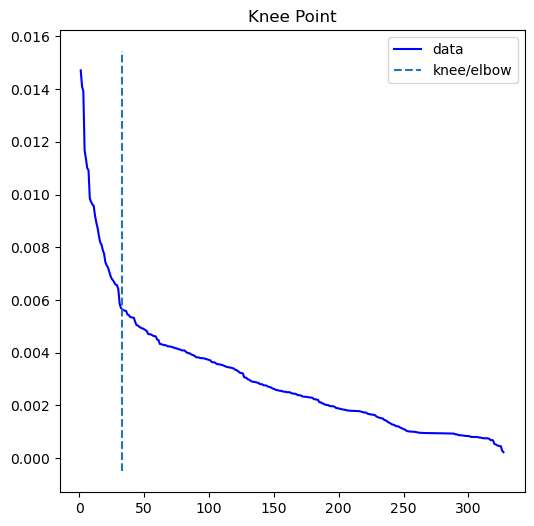

In [17]:
locator.plot_knee()

In [18]:
important_features = feature_importances.head(n_kneedle).index
print(f"Selected {len(important_features)} features based on elbow method")

Selected 33 features based on elbow method


In [19]:
# Subset of combined dataset with important features only
mc_profiles_rf_subset = mc_profiles[important_features]
nomc_profiles_rf_subset = nomc_profiles[important_features]

combined_rf_subset = combined[important_features]
print(f"Combined dataset with selected features: {combined_rf_subset.shape}")


Combined dataset with selected features: (51, 33)


In [20]:
scenario_profiles = {
    "full_features": (mc_profiles, nomc_profiles, combined),
    "rf_features": (mc_profiles_rf_subset, nomc_profiles_rf_subset, combined_rf_subset),
    "pca_features": (mc_profiles_pca_subset, nomc_profiles_pca_subset, combined_pca_subset),
}


## 3. Similarity Functions

In [21]:
def cosine_similarity(a: np.ndarray, B: np.ndarray) -> np.ndarray:
    a_norm = a / (np.linalg.norm(a) + 1e-12)
    B_norm = B / (np.linalg.norm(B, axis=1, keepdims=True) + 1e-12)
    return B_norm @ a_norm

def pearson_similarity(a: np.ndarray, B: np.ndarray) -> np.ndarray:
    a_c = a - a.mean()
    B_c = B - B.mean(axis=1, keepdims=True)
    num = B_c @ a_c
    denom = np.linalg.norm(a_c) * np.linalg.norm(B_c, axis=1) + 1e-12
    return num / denom

def euclidean_similarity(a: np.ndarray, B: np.ndarray) -> np.ndarray:
    dists = np.linalg.norm(B - a, axis=1)
    return 1.0 / (1.0 + dists)

def spearman_similarity(a: np.ndarray, B: np.ndarray) -> np.ndarray:
    return np.array([spearmanr(a, row).statistic for row in B])

def mahalanobis_similarity(a: np.ndarray, B: np.ndarray) -> np.ndarray:
    mask = np.isfinite(B).all(axis=0)
    B_clean = B[:, mask]
    a_clean = a[mask]
    if B_clean.shape[0] <= 1:
        dists = np.linalg.norm(B_clean - a_clean, axis=1)
        return 1.0 / (1.0 + dists)
    cov = np.cov(B_clean.T)
    cov_inv = np.linalg.inv(cov + np.eye(cov.shape[0]) * 1e-6)
    dists = np.array([np.sqrt((row - a_clean) @ cov_inv @ (row - a_clean)) for row in B_clean])
    return 1.0 / (1.0 + dists)

METRICS = {
    'cosine':      cosine_similarity,
    'pearson':     pearson_similarity,
    'euclidean':   euclidean_similarity,
    'spearman':    spearman_similarity,
    'mahalanobis': mahalanobis_similarity,
}


## Dynamic Tree Cut Imports and Functions

In [22]:
from dynamicTreeCut import cutreeHybrid

PALETTE = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
    '#aec7e8', '#ffbb78', '#98df8a', '#ff9896', '#c5b0d5'
]

def dynamictreecut_plot(linkage_matrix, labels_compounds, result, title='MC Profile Dendrogram — Dynamic Tree Cut\n'
                 '(complete linkage, correlation distance)', figsize=(14, 6), save_path=None):
    """
    Dendrogram colored by Dynamic Tree Cut clusters.

    Parameters
    ----------
    linkage_matrix  : np.ndarray   scipy linkage matrix (n-1 x 4)
    labels_compounds: list[str]    compound names (same order as the matrix)
    result          : dict         cutreeHybrid output (must contain 'labels')
    figsize         : tuple        figure size
    save_path       : str | None   path to save the figure to (None = don't save)

    Returns
    -------
    fig, ax, df_clusters : matplotlib Figure, Axes, cluster assignment DataFrame
    """
    n              = len(labels_compounds)
    labels_dynamic = np.array(result['labels'])
    unique_clusters = sorted(set(labels_dynamic))

    # Color palette: cluster 0 is "unassigned" by dynamicTreeCut convention
    color_map = {0: '#aaaaaa'}
    for i, cid in enumerate(c for c in unique_clusters if c != 0):
        color_map[cid] = PALETTE[i % len(PALETTE)]

    compound_color = {
        cpd: color_map[lab]
        for cpd, lab in zip(labels_compounds, labels_dynamic)
    }

    # Summary DataFrame of cluster assignments
    df_clusters = (
        pd.DataFrame({'compound': labels_compounds, 'cluster': labels_dynamic})
        .sort_values('cluster')
        .reset_index(drop=True)
    )

    # Color dendrogram branches by the cluster of the leaves they subtend
    def leaves_under(node):
        if node < n:
            return {node}
        l = int(linkage_matrix[node - n, 0])
        r = int(linkage_matrix[node - n, 1])
        return leaves_under(l) | leaves_under(r)

    def get_link_color(link_id):
        clusters = {labels_dynamic[i] for i in leaves_under(link_id)}
        if len(clusters) == 1:
            return color_map.get(clusters.pop(), '#cccccc')
        return '#cccccc'

    fig, ax = plt.subplots(figsize=figsize)

    dendrogram(
        linkage_matrix,
        ax=ax,
        labels=labels_compounds,
        link_color_func=get_link_color,
        leaf_rotation=90,
        leaf_font_size=8,
    )

    for lbl in ax.get_xticklabels():
        lbl.set_color(compound_color.get(lbl.get_text(), '#000000'))
        lbl.set_fontweight('bold')

    # Legend
    patches = ([mpatches.Patch(color='#aaaaaa', label='Unassigned')]
               if 0 in unique_clusters else [])

    for cid in (c for c in unique_clusters if c != 0):
        members = df_clusters[df_clusters['cluster'] == cid]['compound'].tolist()
        short   = ', '.join(members[:2]) + ('…' if len(members) > 2 else '')
        patches.append(mpatches.Patch(
            color=color_map[cid],
            label=f'Cluster {cid} (n={len(members)})  {short}'
        ))

    ax.legend(handles=patches, bbox_to_anchor=(1.01, 1),
              loc='upper left', fontsize=7.5, framealpha=0.9)

    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Distance')
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f'Figure saved -> {save_path}')

    return fig, ax, df_clusters


## 4. MC and NOMC Cluster Derivation

In [23]:
nomc_arr = nomc_profiles.values
linkage_matrix_nomc = linkage(nomc_arr, method='complete', metric='correlation')


..cutHeight not given, setting it to 1.387101340693567  ===>  99% of the (truncated) height range in dendro.
Figure saved -> ../../figures/GBA/dendrogram_dynamic_tree_cut_NOMC.png


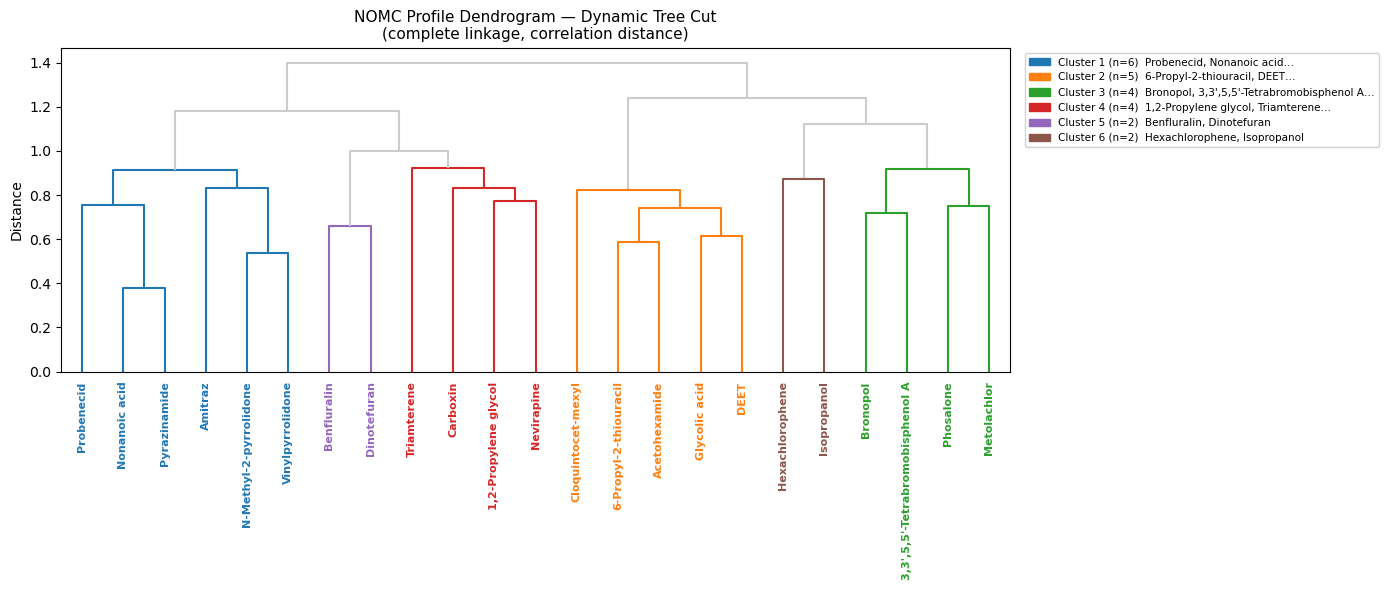

In [24]:
dist_matrix = squareform(pdist(nomc_arr, metric='correlation'))

result_nomc = cutreeHybrid(
    link=linkage_matrix_nomc,
    distM=dist_matrix,
    minClusterSize=2,
    deepSplit=1,
    pamRespectsDendro=True,
    verbose=0
)

fig, ax, df_clusters = dynamictreecut_plot(
    linkage_matrix  = linkage_matrix_nomc,
    labels_compounds = labels_compounds_nomc,
    result          = result_nomc,
    figsize         = (14, 6),
    save_path       = '../../figures/GBA/dendrogram_dynamic_tree_cut_NOMC.png',
    title = 'NOMC Profile Dendrogram — Dynamic Tree Cut\n'
                 '(complete linkage, correlation distance)'
    
)

plt.show()
# print(df_clusters)

In [25]:
nomc_cluster_labels = result_nomc['labels']  # dynamic tree cut, not a fixed-height cut
nomc_clusters = pd.Series(nomc_cluster_labels, index=nomc_profiles.index, name='cluster')

n_nomc_clusters = nomc_cluster_labels.max()
print(f'NOMC clusters selected by dynamic tree cut: {n_nomc_clusters}')
print(nomc_clusters.value_counts().sort_index())


NOMC clusters selected by dynamic tree cut: 6
cluster
1    6
2    5
3    4
4    4
5    2
6    2
Name: count, dtype: int64


In [26]:
mc_arr = mc_profiles.values
linkage_matrix_mc = linkage(mc_arr, method='complete', metric='correlation')


..cutHeight not given, setting it to 1.4957384316366023  ===>  99% of the (truncated) height range in dendro.
Figure saved -> ../../figures/GBA/dendrogram_dynamic_tree_cut_MC.png


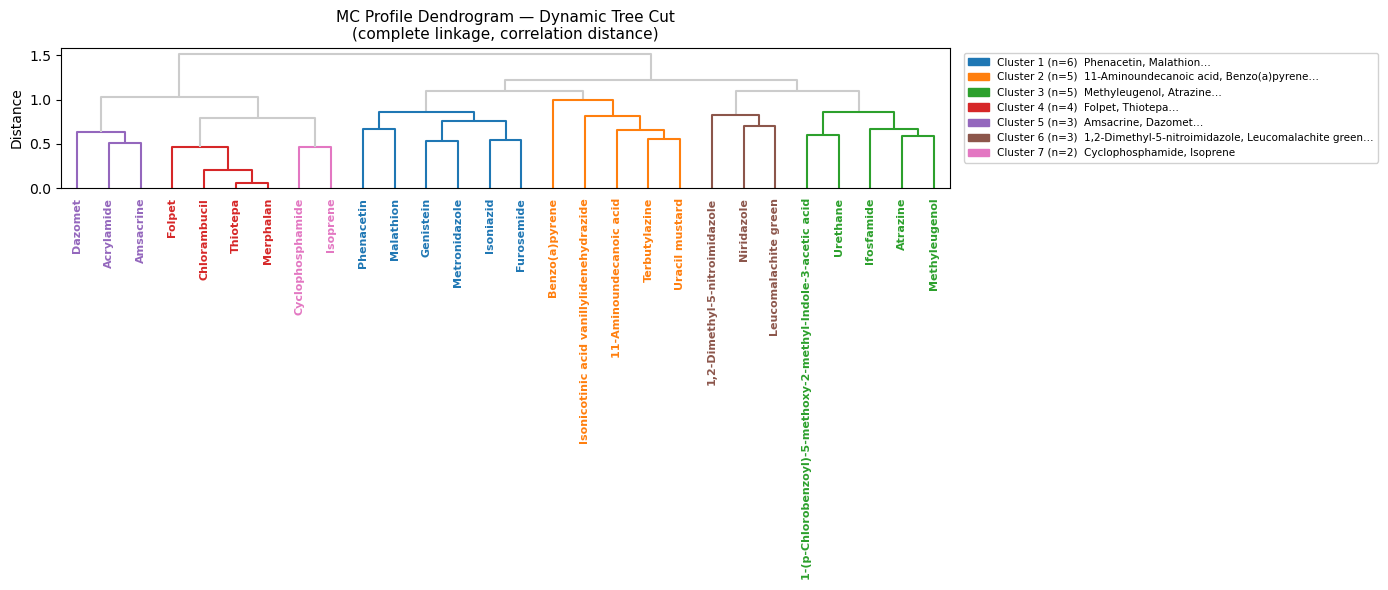

In [27]:
dist_matrix = squareform(pdist(mc_arr, metric='correlation'))

result_mc = cutreeHybrid(
    link=linkage_matrix_mc,
    distM=dist_matrix,
    minClusterSize=2,
    deepSplit=1,
    pamRespectsDendro=True,
    verbose=0
)

fig, ax, df_clusters = dynamictreecut_plot(
    linkage_matrix  = linkage_matrix_mc,
    labels_compounds = labels_compounds_mc,
    result          = result_mc,
    figsize         = (14, 6),
    save_path       = '../../figures/GBA/dendrogram_dynamic_tree_cut_MC.png'
)

plt.show()
# print(df_clusters)

In [28]:
mc_cluster_labels = result_mc['labels']  # dynamic tree cut, not a fixed-height cut
mc_clusters = pd.Series(mc_cluster_labels, index=mc_profiles.index, name='cluster')

n_mc_clusters = mc_cluster_labels.max()
print(f'MC clusters selected by dynamic tree cut: {n_mc_clusters}')
print(mc_clusters.value_counts().sort_index())


MC clusters selected by dynamic tree cut: 7
cluster
1    6
2    5
3    5
4    4
5    3
6    3
7    2
Name: count, dtype: int64


## 5. GBA Scoring Functions

In [29]:
# ── Normalization constants ───────────────────────────────────────────────────
# sim ∈ (0,1]  → max difference = 1  → α = 1
# sim ∈ [-1,1] → max difference = 2  → α = 2
METRIC_ALPHA = {
    'euclidean':   1.0,
    'mahalanobis': 1.0,
    'cosine':      2.0,
    'pearson':     2.0,
    'spearman':    2.0,
}

def gba_score_individual(query, mc_ref, nomc_ref, sim_fn, top_k=None, alpha=1.0):
    sim_mc   = sim_fn(query, mc_ref)
    sim_nomc = sim_fn(query, nomc_ref)
    if top_k is not None:
        sim_mc   = np.sort(sim_mc)[-top_k:]
        sim_nomc = np.sort(sim_nomc)[-top_k:]
    return float((sim_mc.mean() - sim_nomc.mean()) / alpha)

def gba_score_cluster_centroids(query, mc_centroids, nomc_centroids, sim_fn, alpha=1.0):
    sim_mc   = sim_fn(query, mc_centroids)
    sim_nomc = sim_fn(query, nomc_centroids)
    return float((sim_mc.max() - sim_nomc.max()) / alpha)

def gba_score_max_mc_mean_nomc(query, mc_centroids, nomc_ref, sim_fn, top_k=5, alpha=1.0):
    """
    Captures resemblance to ANY MC mechanism (max over cluster centroids)
    vs stable NOMC background (top-k mean over individuals).
    Rationale: a compound need only resemble ONE MC mechanism to be at risk,
    but should be dissimilar to the full NOMC space.
    """
    sim_mc   = sim_fn(query, mc_centroids)        # one value per MC cluster
    sim_nomc = sim_fn(query, nomc_ref)             # one value per NOMC compound
    if top_k is not None:
        sim_nomc = np.sort(sim_nomc)[-top_k:]      # focus on most similar NOMC
    return float((sim_mc.max() - sim_nomc.mean()) / alpha)


## 6. LOOCV Validation

In [30]:
SCENARIO = "pca_features"  # "full_features" or "pca_features" or "rf_features"

# ---------------------------------------------------------------------------
# IMPORTANT (fix for feature-selection leakage):
# For SCENARIO == "rf_features", feature selection (RandomForest importances +
# Kneedle elbow) is redone INSIDE the LOOCV loop below, using only the N-1
# compounds other than the one being scored. This is a "nested LOOCV": the
# held-out compound's label never contributes to choosing the features it is
# then evaluated on. For "full_features" / "pca_features", no supervised
# feature selection happens, so no nesting is needed for those scenarios.
#
# This matters a lot here: an earlier (pre-fix) version of this notebook
# selected the 33 "important" features ONCE on a single 80/20 split of all 51
# compounds (see `important_features`, Section 2 above) and reused that same
# set for every LOOCV fold. That is textbook feature-selection leakage
# (Ambroise & McLachlan 2002, PNAS) and it is what originally produced the
# inflated RF-feature-space numbers (best AUC-ROC 0.716, hybrid+Spearman).
# The nested version below is the methodologically correct one and is what
# this notebook now reports. See "6.1 Feature-Selection Stability" further
# down for why the corrected numbers are noticeably lower, not just leakage
# removal but genuine per-fold feature-selection instability at this sample
# size (N=51, p=748).
#
# NOTE: clustering here is performed in the SCENARIO's own feature
# representation (full / PCA / RF-selected), matching what is actually
# validated by each scenario's LOOCV number. This differs from the EDList
# prospective-scoring cell further down, which clusters in the full feature
# space regardless of scenario (reusing the Section 4 assignments) -- an
# intentional choice, since MC/Non-MC mechanistic subgroups are established
# from the descriptive analysis (Section 3.1) in the full feature space.
# ---------------------------------------------------------------------------

if SCENARIO == "rf_features":
    # Nested feature selection needs the FULL feature space as its source
    # (NOT the already globally-selected 33-feature subset).
    mc_profiles_full, nomc_profiles_full, combined_full = scenario_profiles["full_features"]
    all_compounds = combined_full.index.tolist()
else:
    mc_profiles, nomc_profiles, combined = scenario_profiles[SCENARIO]
    all_compounds = combined.index.tolist()

results = []
fold_feature_records = []  # per-fold feature-selection diagnostics (rf_features only)
N_ESTIMATORS_LOO = 100  # same as the global RF above

for i, compound_id in enumerate(all_compounds):
    true_label = y[compound_id]

    if SCENARIO == "rf_features":
        # ---------------------------------------------------------------
        # Nested feature selection: retrain RF + Kneedle elbow using ONLY
        # the other compounds (compound_id excluded). The features used to
        # score this compound never saw its label.
        # ---------------------------------------------------------------
        train_ids_loo = [c for c in all_compounds if c != compound_id]
        X_train_loo = combined_full.loc[train_ids_loo]
        y_train_loo = y.loc[train_ids_loo]

        rf_loo = RandomForestClassifier(n_estimators=N_ESTIMATORS_LOO, random_state=RANDOM_STATE)
        rf_loo.fit(X_train_loo, y_train_loo)

        importances_loo = pd.Series(
            rf_loo.feature_importances_, index=combined_full.columns
        ).sort_values(ascending=False)

        n_features_loo, _ = find_features_by_kneedle(importances_loo, sensitivity=1.0, verbose=False)
        important_features_loo = importances_loo.head(n_features_loo).index

        fold_feature_records.append({
            'compound_id': compound_id,
            'n_features': n_features_loo,
            'features': frozenset(important_features_loo),
        })

        query = combined_full.loc[compound_id, important_features_loo].values

        mc_ref_ids   = [c for c in mc_profiles_full.index   if c != compound_id]
        nomc_ref_ids = [c for c in nomc_profiles_full.index if c != compound_id]
        mc_ref   = mc_profiles_full.loc[mc_ref_ids, important_features_loo].values
        nomc_ref = nomc_profiles_full.loc[nomc_ref_ids, important_features_loo].values
    else:
        # No supervised feature selection for these scenarios -- nothing to
        # redo per-fold, dimensions are already consistent across the board.
        query = combined.loc[compound_id].values

        mc_ref_ids   = [c for c in mc_profiles.index   if c != compound_id]
        nomc_ref_ids = [c for c in nomc_profiles.index if c != compound_id]
        mc_ref   = mc_profiles.loc[mc_ref_ids].values
        nomc_ref = nomc_profiles.loc[nomc_ref_ids].values

    # Clusters (and their centroids) are recomputed on EVERY LOO fold, excluding
    # the query compound -- this avoids leaking the held-out compound into the
    # cluster structure it is then compared against. Also done in the
    # fold-specific feature space when SCENARIO == "rf_features".
    lm_mc_loo = linkage(mc_ref, method='complete', metric='correlation')
    dist_matrix_mc = squareform(pdist(mc_ref, metric='correlation'))
    result_mc_loo = cutreeHybrid(link=lm_mc_loo, distM=dist_matrix_mc, minClusterSize=2, deepSplit=1, pamRespectsDendro=True, verbose=0)
    cluster_labels_mc_loo = result_mc_loo['labels']
    mc_centroids_loo = (
        pd.DataFrame(mc_ref).assign(cluster=cluster_labels_mc_loo).groupby('cluster').mean().values
    )
    lm_nomc_loo = linkage(nomc_ref, method='complete', metric='correlation')
    dist_matrix_nomc = squareform(pdist(nomc_ref, metric='correlation'))
    result_nomc_loo = cutreeHybrid(link=lm_nomc_loo, distM=dist_matrix_nomc, minClusterSize=2, deepSplit=1, pamRespectsDendro=True, verbose=0)
    cluster_labels_nomc_loo = result_nomc_loo['labels']
    nomc_centroids_loo = (
        pd.DataFrame(nomc_ref).assign(cluster=cluster_labels_nomc_loo).groupby('cluster').mean().values
    )

    # Sanity check: query and both centroid matrices must live in the same feature space.
    assert query.shape[0] == mc_centroids_loo.shape[1] == nomc_centroids_loo.shape[1], (
        f"Feature-dimension mismatch at compound {compound_id}: "
        f"query={query.shape[0]}, mc_centroids={mc_centroids_loo.shape[1]}, "
        f"nomc_centroids={nomc_centroids_loo.shape[1]}"
    )

    for metric_name, sim_fn in METRICS.items():
        alpha = METRIC_ALPHA[metric_name]
        s1 = gba_score_individual(query, mc_ref, nomc_ref, sim_fn, top_k=5, alpha=alpha)
        s2 = gba_score_cluster_centroids(query, mc_centroids_loo, nomc_centroids_loo, sim_fn, alpha=alpha)
        s3 = gba_score_max_mc_mean_nomc(query, mc_centroids_loo, nomc_ref, sim_fn, top_k=5, alpha=alpha)
        for strategy, score in [('individual', s1), ('cluster_centroids', s2), ('hybrid', s3)]:
            results.append({
                'compound_id': compound_id,
                'true_label':  true_label,
                'y_true':      1 if true_label == 'MC' else 0,
                'metric':      metric_name,
                'strategy':    strategy,
                'score':       score,
            })

    if (i + 1) % 10 == 0 or (i + 1) == len(all_compounds):
        print(f'  ... {i + 1}/{len(all_compounds)} compounds processed')

results_df = pd.DataFrame(results)
print(f'LOOCV done ({SCENARIO}): {len(all_compounds)} compounds x {len(METRICS)} metrics x 3 strategies = {len(results_df)} rows')

# For SCENARIO == "rf_features", `mc_profiles` / `nomc_profiles` / `combined` are NOT
# globally rebound here -- each fold used its own fold-specific feature subset
# (`important_features_loo`), so there is no single fixed 33-feature space to rebind
# these names to. The EDList1/EDList2 scoring section further down intentionally uses
# the GLOBAL `important_features` instead, which is fine: those compounds are external
# and never participated in this LOOCV or in choosing `important_features`, so there
# is no leakage in using the global selection for them.


..cutHeight not given, setting it to 1.9532522948000435  ===>  99% of the (truncated) height range in dendro.
..cutHeight not given, setting it to 1.918635127174366  ===>  99% of the (truncated) height range in dendro.
..cutHeight not given, setting it to 1.9532522948000435  ===>  99% of the (truncated) height range in dendro.
..cutHeight not given, setting it to 1.918635127174366  ===>  99% of the (truncated) height range in dendro.
..cutHeight not given, setting it to 1.9532522948000435  ===>  99% of the (truncated) height range in dendro.
..cutHeight not given, setting it to 1.918635127174366  ===>  99% of the (truncated) height range in dendro.
..cutHeight not given, setting it to 1.9532522948000435  ===>  99% of the (truncated) height range in dendro.
..cutHeight not given, setting it to 1.918635127174366  ===>  99% of the (truncated) height range in dendro.
..cutHeight not given, setting it to 1.9533726487485281  ===>  99% of the (truncated) height range in dendro.
..cutHeight no

## 6.1 Feature-Selection Stability (RF-selected scenario)

The nested LOOCV above reselects the "important" RF features independently on
every fold (N-1 = 50 compounds). This is the methodologically correct way to
avoid feature-selection leakage, but it raises a natural question: given that
each fold only excludes a single compound out of 51, shouldn't the selected
feature sets be nearly identical fold-to-fold, and close to the single
80/20-split `important_features` set used elsewhere (e.g. for EDList
scoring)?

They are not. The diagnostic below shows that (i) the number of features
selected per fold swings widely (not a stable ~33), (ii) each fold's set
shares only a handful of features with the globally-selected 33-feature set,
and (iii) even two arbitrary folds -- differing by just one compound -- only
share roughly a third of their selected features. This means the RandomForest
importance + Kneedle-elbow selection is intrinsically unstable at this sample
size (N=51, p=748): dropping a single compound reshuffles which features look
"important". The 33-feature list is therefore not a robust, reproducible
signature -- it is closely tied to the exact 51-compound sample it was fit
on.

This instability, on top of the leakage itself, is why the nested LOOCV
RF-feature-space performance (Section 7 below) is substantially lower than
what a single, globally-selected feature set appears to achieve when
(incorrectly) reused across all folds.

In [ ]:
# Reference set: the single, globally-selected 33-feature set used elsewhere
# in this notebook (Section 2, `important_features`) -- computed once on an
# 80/20 split of all 51 compounds, i.e. exactly the set that a non-nested
# LOOCV would have leaked into every fold.
if not fold_feature_records:
    print(f"SCENARIO == '{SCENARIO}': no per-fold RF feature selection was performed "
          "(nested feature reselection only happens for SCENARIO == 'rf_features'). "
          "Re-run the LOOCV cell above with SCENARIO = 'rf_features' to populate this diagnostic.")
else:
    global_feature_set = frozenset(important_features)

    fold_df = pd.DataFrame(fold_feature_records)
    fold_df['overlap_with_global'] = fold_df['features'].apply(lambda s: len(s & global_feature_set))
    fold_df['jaccard_vs_global'] = fold_df.apply(
        lambda r: len(r['features'] & global_feature_set) / len(r['features'] | global_feature_set), axis=1
    )

    print(f"Global (leaky, once-only) feature-set size: {len(global_feature_set)}")
    print("\n=== Per-fold feature count ===")
    display(fold_df['n_features'].describe())
    print("\n=== Overlap with the global 33-feature set (features in common) ===")
    display(fold_df['overlap_with_global'].describe())
    print("\n=== Jaccard similarity: fold set vs. global set ===")
    display(fold_df['jaccard_vs_global'].describe())

    # Pairwise stability between folds themselves (all 51 choose 2 = 1275 pairs)
    fold_sets = fold_df['features'].tolist()
    pairwise_jaccard = [
        len(a & b) / len(a | b)
        for a, b in itertools.combinations(fold_sets, 2)
    ]
    print(f"\n=== Pairwise Jaccard between folds ({len(pairwise_jaccard)} pairs) ===")
    display(pd.Series(pairwise_jaccard, name='jaccard').describe())

    # Map compound_id to compound name using the metadata dataframe
    fold_df['compound_name'] = fold_df['compound_id'].map(
        metadata_combined_jumpcp_df.set_index('JCP2022')['Name']
    )

    # Save per-fold diagnostics including both compound_id and compound_name
    fold_df[['compound_id', 'compound_name', 'n_features', 'overlap_with_global', 'jaccard_vs_global']].to_csv(
        '../../data/results_tables/GBA_rf_feature_selection_stability.csv', index=False
    )
    
    print("\nSaved per-fold diagnostics to data/results_tables/GBA_rf_feature_selection_stability.csv")

SCENARIO == 'pca_features': no per-fold RF feature selection was performed (nested feature reselection only happens for SCENARIO == 'rf_features'). Re-run the LOOCV cell above with SCENARIO = 'rf_features' to populate this diagnostic.


## 7. Performance Evaluation

In [32]:
def evaluate_group(grp: pd.DataFrame) -> pd.Series:
    y_true = grp['y_true'].values
    scores = grp['score'].values
    y_pred = (scores >= 0).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return pd.Series({
        'AUC-ROC':     round(roc_auc_score(y_true, scores), 3),
        'AUC-PR':      round(average_precision_score(y_true, scores), 3),
        'MCC':         round(matthews_corrcoef(y_true, y_pred), 3),
        'Bal.Acc':     round(balanced_accuracy_score(y_true, y_pred), 3),
        'Sensitivity': round(sensitivity, 3),
        'Specificity': round(specificity, 3),
    })

perf_df = (
    results_df
    .groupby(['strategy', 'metric'])
    .apply(evaluate_group)
    .reset_index()
    .sort_values(['strategy', 'AUC-PR'], ascending=[True, False])
)
display(perf_df)


,strategy,metric,AUC-ROC,AUC-PR,MCC,Bal.Acc,Sensitivity,Specificity
0,cluster_centroids,cosine,0.630,0.696,0.155,0.575,0.714,0.435
3,cluster_centroids,pearson,0.607,0.676,0.236,0.610,0.786,0.435
1,cluster_centroids,euclidean,0.554,0.655,0.117,0.557,0.679,0.435
2,cluster_centroids,mahalanobis,0.408,0.595,0.000,0.500,1.000,0.000
4,cluster_centroids,spearman,0.443,0.561,-0.128,0.438,0.571,0.304
6,hybrid,euclidean,0.528,0.665,-0.116,0.448,0.679,0.217
8,hybrid,pearson,0.585,0.639,0.097,0.533,0.893,0.174
5,hybrid,cosine,0.545,0.629,0.148,0.559,0.857,0.261
9,hybrid,spearman,0.439,0.587,-0.204,0.408,0.643,0.174
7,hybrid,mahalanobis,0.331,0.499,-0.294,0.352,0.357,0.348


In [33]:
# Scenario-specific, non-duplicated outputs -- SCENARIO is set in Section 6
# above ("full_features", "pca_features", or "rf_features"), and both files
# below are named after it so re-running with a different SCENARIO can never
# silently overwrite another scenario's results.
results_df.to_csv(f'../../data/results_tables/GBA_loocv_scores_{SCENARIO}.csv', index=False)
perf_df.to_csv(f'../../data/results_tables/GBA_loocv_performance_{SCENARIO}.csv', index=False)
print(f'Saved GBA_loocv_scores_{SCENARIO}.csv and GBA_loocv_performance_{SCENARIO}.csv')


Saved GBA_loocv_scores_pca_features.csv and GBA_loocv_performance_pca_features.csv


## Assessment of risk compounds based on similarity

Chosen configuration: across the three feature-space scenarios evaluated above
(Section 7), cluster-centroid scoring with cosine similarity on the 16-component
PCA representation gives the best legitimate LOOCV performance (AUC-ROC = 0.630,
AUC-PR = 0.696 - `gba_performance_summary_pca_features.csv`), ahead of the
RF-selected-feature scenario once its per-fold feature-selection instability is
accounted for (Section 6.1) and of the full-feature-space scenario. This
configuration - cluster centroids, cosine similarity, PCA-reduced features - is
used below to score the EDList I and EDList II candidates.

In [34]:
edlists_dataset = pd.read_csv("../../data/chemicals/ED_Lists/ED_lists_combined.csv").sort_values(
    by=["ID (for name)", "Year"]).drop_duplicates(
        subset=["InChIKey"], keep="last").dropna(
            subset=["InChIKey"])


In [35]:
# ── Apply GBA (cluster_centroids, cosine, pca_features) to EDList1 & EDList2 ──
# PCA was fitted on MC+NOMC combined (Section 2) -- edlist{1,2}_pca_subset use
# pca.transform(). Cluster centroids reuse the MC/Non-MC cluster assignments
# from Section 4 (dynamic tree cut on the full feature space), recomputed as
# centroids in PCA space. Full reference sets are used (no LOO needed:
# EDList1/EDList2 are external to training).
sim_fn = METRICS["cosine"]
alpha  = METRIC_ALPHA["cosine"]

mc_cluster_centroids_pca = (
    mc_profiles_pca_subset.assign(cluster=mc_cluster_labels).groupby('cluster').mean().values
)
nomc_cluster_centroids_pca = (
    nomc_profiles_pca_subset.assign(cluster=nomc_cluster_labels).groupby('cluster').mean().values
)

edlist1_results = []
edlist2_results = []

## ED LIST 1
for compound_id in edlist1_pca_subset.index:
    query = edlist1_pca_subset.loc[compound_id].values
    score = gba_score_cluster_centroids(
        query,
        mc_cluster_centroids_pca,
        nomc_cluster_centroids_pca,
        sim_fn,
        alpha=alpha,
    )
    edlist1_results.append({
        "compound_id": compound_id,
        "score":       score,
        "predicted":   "MC-like" if score >= 0 else "NOMC-like",
    })

edlist1_scores_df = pd.DataFrame(edlist1_results).sort_values("score", ascending=False)

# Resolve compound names: JCP2022 → InChIKey → Name
_jcp_to_ikey = (
    metadata_jumpcp_df[["JCP2022", "INCHIKEY"]]
    .drop_duplicates()
    .set_index("JCP2022")["INCHIKEY"]
    .to_dict()
)
edlist1_scores_df["InChIKey"] = edlist1_scores_df["compound_id"].map(_jcp_to_ikey)

edlist1_scores_df = edlist1_scores_df.merge(
    edlists_dataset[["InChIKey", "Name and abbreviation", "CAS no."]].drop_duplicates(),
    on="InChIKey",
    how="left",
)
edlist1_scores_df["score"] = edlist1_scores_df["score"].round(4)

display(edlist1_scores_df[["compound_id", "Name and abbreviation", "CAS no.", "score", "predicted"]].set_index("compound_id"))

## ED LIST 2
for compound_id in edlist2_pca_subset.index:
    query = edlist2_pca_subset.loc[compound_id].values
    score = gba_score_cluster_centroids(
        query,
        mc_cluster_centroids_pca,
        nomc_cluster_centroids_pca,
        sim_fn,
        alpha=alpha,
    )
    edlist2_results.append({
        "compound_id": compound_id,
        "score":       score,
        "predicted":   "MC-like" if score >= 0 else "NOMC-like",
    })

edlist2_scores_df = pd.DataFrame(edlist2_results).sort_values("score", ascending=False)

# Resolve compound names: JCP2022 → InChIKey → Name
edlist2_scores_df["InChIKey"] = edlist2_scores_df["compound_id"].map(_jcp_to_ikey)
edlist2_scores_df = edlist2_scores_df.merge(
    edlists_dataset[["InChIKey", "Name and abbreviation", "CAS no."]].drop_duplicates(),
    on="InChIKey",
    how="left",
)
edlist2_scores_df["score"] = edlist2_scores_df["score"].round(4)

display(edlist2_scores_df[["compound_id", "Name and abbreviation", "CAS no.", "score", "predicted"]].set_index("compound_id"))

# Save EDList1/2 scores to CSV
edlist1_scores_df.to_csv('../../data/results_tables/GBA_EDList1_scores_cluster_centroids_cosine_pca.csv', index=False)
edlist2_scores_df.to_csv('../../data/results_tables/GBA_EDList2_scores_cluster_centroids_cosine_pca.csv', index=False)
print('Saved GBA scores for EDList1 and EDList2 (cluster_centroids, cosine, PCA features).')

,Name and abbreviation,CAS no.,score,predicted
compound_id,,,,
JCP2022_092114,Clofentezine,74115-24-5,0.3127,MC-like
JCP2022_029699,"(±)-1,7,7-trimethyl-3-[(4-methylphenyl)methyle...",36861-47-9,0.0693,MC-like
JCP2022_013451,Medetomidine,86347-14-0,0.0321,MC-like
JCP2022_064048,"1,7,7-trimethyl-3-[(4-methylphenyl)methylene]b...",15087-24-8,0.0310,MC-like
JCP2022_073093,Butyl 4-hydroxybenzoate; Butylparaben,94-26-8,-0.0076,NOMC-like
JCP2022_017185,Dibutyl phthalate (DBP),84-74-2,-0.0387,NOMC-like
JCP2022_035308,"4,4'-isopropylidenediphenol; Bisphenol A",80-05-7,-0.0431,NOMC-like
JCP2022_036912,Benzyl butyl phthalate (BBP),85-68-7,-0.0943,NOMC-like
JCP2022_037041,"4-(1,1,3,3-tetramethylbutyl)phenol",140-66-9,-0.1860,NOMC-like


,Name and abbreviation,CAS no.,score,predicted
compound_id,,,,
JCP2022_104289,3-methylpyrazole,1453-58-3,0.1271,MC-like
JCP2022_025492,Resorcinol,108-46-3,0.0945,MC-like
JCP2022_055978,2-tert-butyl-4-methoxyphenol (BHA),"25013-16-5, 121-00-6",0.0798,MC-like
JCP2022_099101,Thiabendazole,148-79-8,0.0491,MC-like
JCP2022_059885,"2,6-di-tert-butyl-p-cresol; butylated hydroxyt...",128-37-0,0.0414,MC-like
JCP2022_072896,Propyl 4-hydroxybenzoate; Propylparaben,94-13-3,0.0088,MC-like
JCP2022_052273,Methyl 4-hydroxybenzoate (Methylparaben),99-76-3,-0.0016,NOMC-like
JCP2022_018778,Oxybenzone (BP-3),131-57-7,-0.0080,NOMC-like
JCP2022_104707,"1-[4-(1,1-dimethylethyl)phenyl]-3-(4-methoxyph...",70356-09-1,-0.0107,NOMC-like


Saved GBA scores for EDList1 and EDList2 (cluster_centroids, cosine, PCA features).


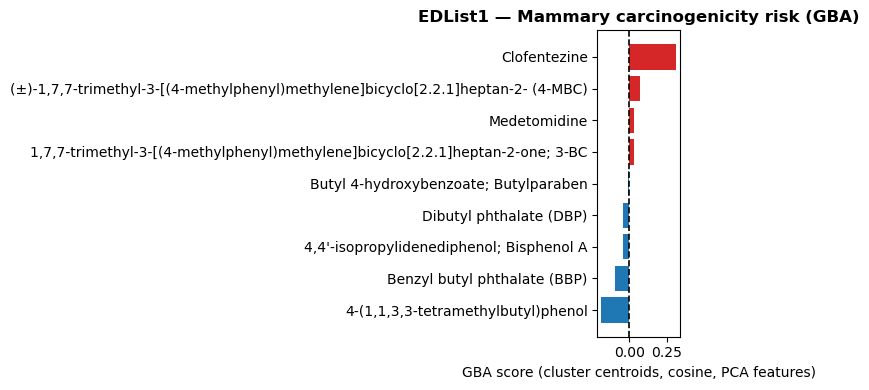

In [36]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#d62728" if s >= 0 else "#1f77b4" for s in edlist1_scores_df["score"]]
labels = edlist1_scores_df["Name and abbreviation"].fillna(edlist1_scores_df["compound_id"])
ax.barh(labels, edlist1_scores_df["score"], color=colors)
ax.axvline(0, color="black", lw=1.2, linestyle="--")
ax.set_xlabel("GBA score (cluster centroids, cosine, PCA features)")
ax.set_title("EDList1 — Mammary carcinogenicity risk (GBA)", weight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../../figures/GBA/GBA_edlist1_cluster_centroids_cosine_pca.png", dpi=200, bbox_inches="tight")
plt.show()

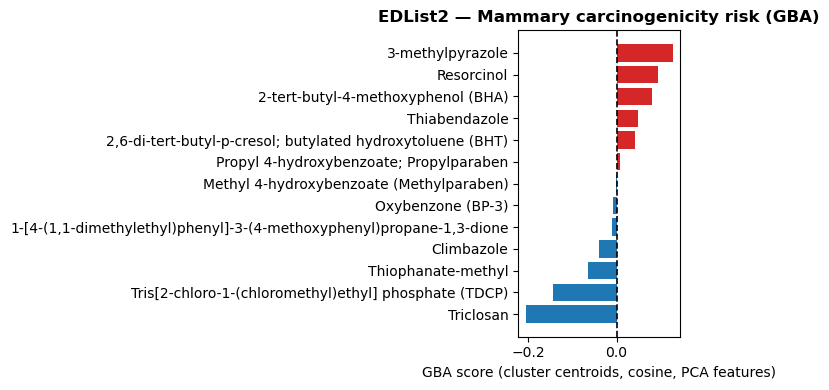

In [37]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#d62728" if s >= 0 else "#1f77b4" for s in edlist2_scores_df["score"]]
labels = edlist2_scores_df["Name and abbreviation"].fillna(edlist2_scores_df["compound_id"])
ax.barh(labels, edlist2_scores_df["score"], color=colors)
ax.axvline(0, color="black", lw=1.2, linestyle="--")
ax.set_xlabel("GBA score (cluster centroids, cosine, PCA features)")
ax.set_title("EDList2 — Mammary carcinogenicity risk (GBA)", weight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../../figures/GBA/GBA_edlist2_cluster_centroids_cosine_pca.png", dpi=200, bbox_inches="tight")
plt.show()